<a href="https://colab.research.google.com/github/wsc-bitspilani/Python-Strats/blob/main/ALPHA_ATR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Processing BPCL.NS...
  Detected MultiIndex columns - flattening structure
  BPCL.NS: Strategy Return=0.44%, B&H Return=30.60%, Trades=1


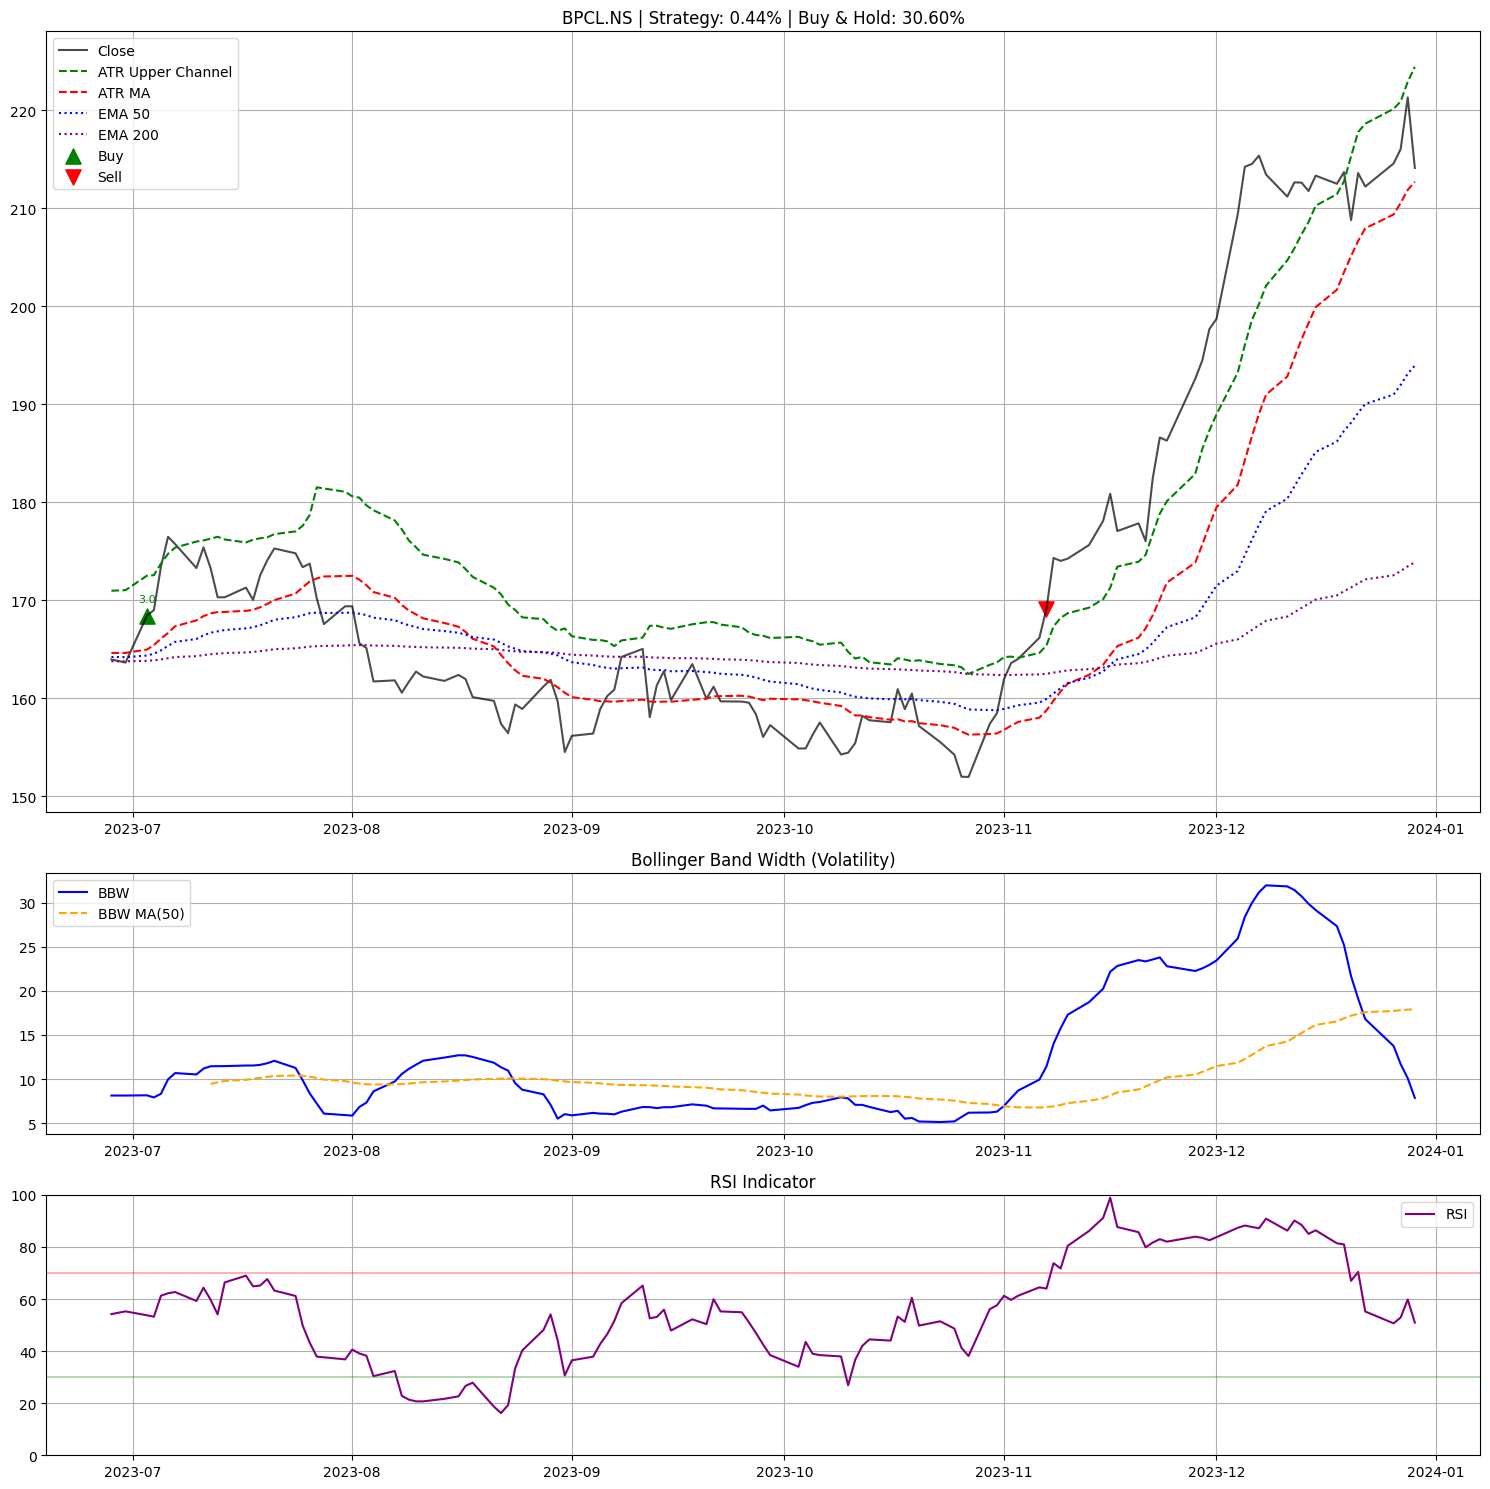

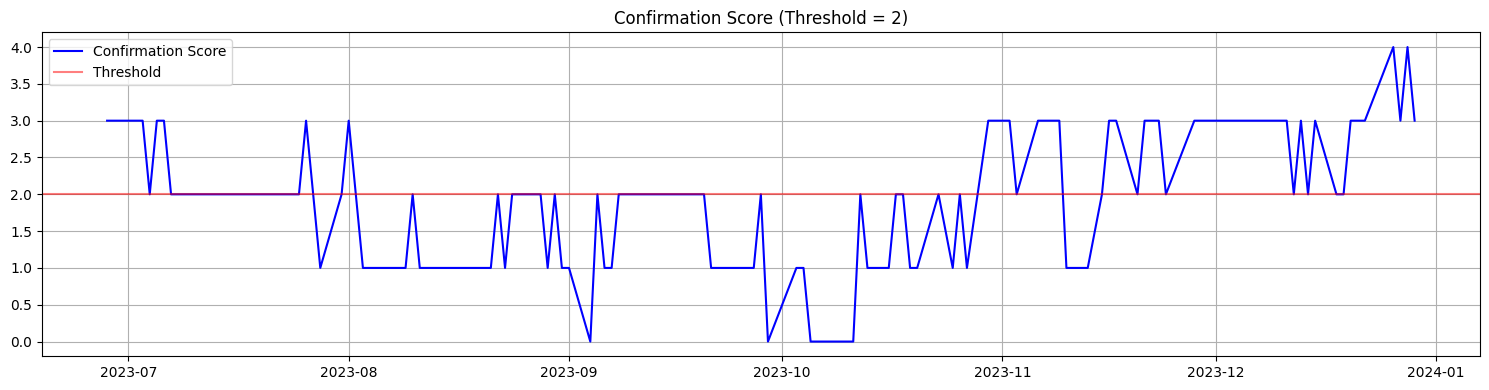


=== BATCH TESTING 49 STOCKS ===
Period: 2024-01-01 to 2025-06-01
--------------------------------------------------
Processing ADANIPORTS.NS...
  Detected MultiIndex columns - flattening structure
  ADANIPORTS.NS: Strategy Return=24.31%, B&H Return=21.19%, Trades=2
Processing ASIANPAINT.NS...
  Detected MultiIndex columns - flattening structure
  ASIANPAINT.NS: Strategy Return=-18.12%, B&H Return=-22.65%, Trades=2
Processing AXISBANK.NS...
  Detected MultiIndex columns - flattening structure
  AXISBANK.NS: Strategy Return=24.85%, B&H Return=13.19%, Trades=5
Processing BAJAJ-AUTO.NS...
  Detected MultiIndex columns - flattening structure
  BAJAJ-AUTO.NS: Strategy Return=34.73%, B&H Return=14.68%, Trades=4
Processing BAJFINANCE.NS...
  Detected MultiIndex columns - flattening structure
  BAJFINANCE.NS: Strategy Return=27.97%, B&H Return=35.34%, Trades=4
Processing BAJAJFINSV.NS...
  Detected MultiIndex columns - flattening structure
  BAJAJFINSV.NS: Strategy Return=39.59%, B&H Return=26

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

def calculate_rsi(series, period=14):
    delta = series.diff().dropna()
    gains = delta.copy()
    losses = delta.copy()
    gains[gains < 0] = 0
    losses[losses > 0] = 0
    losses = abs(losses)
    avg_gain = gains.rolling(window=period, min_periods=1).mean()
    avg_loss = losses.rolling(window=period, min_periods=1).mean()
    rs = avg_gain / avg_loss
    rs = rs.replace([np.inf, -np.inf], np.nan).fillna(0)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def atr_bbw_strategy(ticker, start_date, end_date, initial_cash=100000, show_plots=True):
    print(f"Processing {ticker}...")
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if data.empty or len(data) < 100:
            print(f"  Not enough data for {ticker}")
            return None
        if isinstance(data.columns, pd.MultiIndex):
            print("  Detected MultiIndex columns - flattening structure")
            df = pd.DataFrame(index=data.index)
            if ticker in str(data.columns):
                for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
                    for column in data.columns:
                        if col in column and ticker in column:
                            df[col] = data[column]
            else:
                tickers = data.columns.levels[1] if len(data.columns.levels) > 1 else []
                if len(tickers) > 0:
                    first_ticker = tickers[0]
                    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
                        if (col, first_ticker) in data.columns:
                            df[col] = data[(col, first_ticker)]
                else:
                    df = data.copy()
                    df.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]
            data = df
        required_base_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        missing_cols = [col for col in required_base_cols if col not in data.columns]
        if missing_cols:
            if 'Volume' in missing_cols and len(missing_cols) == 1:
                data['Volume'] = 1
                print("  Created dummy Volume column")
                missing_cols.remove('Volume')
            if missing_cols:
                return None
    except Exception as e:
        print(f"  Error downloading data for {ticker}: {str(e)}")
        return None

    try:
        df = data.copy()
        atr_period = 14
        tr_values = []
        for i in range(len(df)):
            high = df['High'].iloc[i]
            low = df['Low'].iloc[i]
            if i == 0:
                tr_values.append(high - low)
            else:
                prev_close = df['Close'].iloc[i-1]
                tr_values.append(max(
                    high - low,
                    abs(high - prev_close),
                    abs(low - prev_close)
                ))
        df['TR'] = tr_values
        df['ATR'] = df['TR'].ewm(span=atr_period, adjust=False).mean()
        atr_ma_period = 20
        atr_multiplier = 2.0
        df['ATR_MA'] = df['Close'].rolling(window=atr_ma_period).mean()
        df['ATR_Upper'] = df['ATR_MA'] + (df['ATR'] * atr_multiplier)
        bb_period = 20
        df['BB_Middle'] = df['Close'].rolling(window=bb_period).mean()
        df['BB_StdDev'] = df['Close'].rolling(window=bb_period).std()
        df['BB_Middle'] = df['BB_Middle'].replace(0, np.nan)
        df['BBW'] = ((df['BB_Middle'] + 2 * df['BB_StdDev']) -
                     (df['BB_Middle'] - 2 * df['BB_StdDev'])) / df['BB_Middle'] * 100
        df['BBW_ROC'] = df['BBW'].pct_change(periods=10)
        bbw_percentile = []
        lookback = 100
        for i in range(len(df)):
            if i < lookback:
                bbw_percentile.append(np.nan)
            else:
                window = df['BBW'].iloc[i-lookback:i].dropna().values
                if len(window) > 0:
                    current_bbw = df['BBW'].iloc[i]
                    rank = np.sum(window <= current_bbw) / len(window)
                    bbw_percentile.append(rank)
                else:
                    bbw_percentile.append(np.nan)
        df['BBW_Percentile'] = bbw_percentile
        df['RSI'] = calculate_rsi(df['Close'], period=14)
        df['Volume_MA'] = df['Volume'].rolling(window=20).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_MA']
        df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
        df['EMA_200'] = df['Close'].ewm(span=200, adjust=False).mean()
    except Exception as e:
        print(f"  Error calculating indicators for {ticker}: {str(e)}")
        return None

    try:
        df['Above_Upper'] = np.where(df['Close'] > df['ATR_Upper'], 1, 0)
        df['Above_Lower'] = np.where(df['Close'] > df['ATR_MA'], 1, 0)
        buy_crossover = np.zeros(len(df), dtype=bool)
        sell_crossover = np.zeros(len(df), dtype=bool)
        for i in range(1, len(df)):
            sell_crossover[i] = df['Above_Upper'].iloc[i] == 1 and df['Above_Upper'].iloc[i-1] and df['Above_Upper'].iloc[i-2] == 0 and df['Above_Upper'].iloc[i-3] == 0
            buy_crossover[i] = df['Above_Lower'].iloc[i] == 1 and df['Above_Lower'].iloc[i-1] == 0
        df['Buy_Signal'] = buy_crossover
        df['Sell_Signal'] = sell_crossover
        confirmation_scores = np.zeros(len(df))
        for i in range(len(df)):
            score = 0
            if pd.notnull(df['BBW_Percentile'].iloc[i]) and df['BBW_Percentile'].iloc[i] > 0.1:
                score += 1
            if pd.notnull(df['RSI'].iloc[i]) and 40 < df['RSI'].iloc[i] < 80:
                score += 1
            if pd.notnull(df['Volume_Ratio'].iloc[i]) and df['Volume_Ratio'].iloc[i] > 1.0:
                score += 1
            if pd.notnull(df['EMA_50'].iloc[i]) and pd.notnull(df['EMA_200'].iloc[i]):
                if df['EMA_50'].iloc[i] > df['EMA_200'].iloc[i]:
                    score += 1
            confirmation_scores[i] = score
        df['Confirmation_Score'] = confirmation_scores
        df['Confirm'] = df['Confirmation_Score'] >= 2
        nconfirmation_scores = np.zeros(len(df))
        for i in range(len(df)):
            score = 0
            if pd.notnull(df['BBW_Percentile'].iloc[i]) and df['BBW_Percentile'].iloc[i] > 0.2:
                score += 1
            if pd.notnull(df['RSI'].iloc[i]) and 40 < df['RSI'].iloc[i] > 30:
                score += 1
            if pd.notnull(df['Volume_Ratio'].iloc[i]) and df['Volume_Ratio'].iloc[i] > 1.0:
                score += 1
            if pd.notnull(df['EMA_50'].iloc[i]) and pd.notnull(df['EMA_200'].iloc[i]):
                if df['EMA_50'].iloc[i] < df['EMA_200'].iloc[i]:
                    score += 1
            nconfirmation_scores[i] = score
        df['NConfirmation_Score'] = nconfirmation_scores
        df['NConfirm'] = df['Confirmation_Score'] >= 3
       # df['NC'] = df['Confirmation_Score'] <= 2
        df['BUY'] = df['Buy_Signal'] & df['Confirm']
        df['SELL'] = df['Sell_Signal'] & df['NConfirm']
        backtest_cols = ['Close', 'ATR_MA', 'ATR_Upper', 'BUY', 'SELL']
        df_backtest = df.dropna(subset=backtest_cols)
        if len(df_backtest) < 50:
            print(f"  Not enough clean data for {ticker} after filtering")
            return None
    except Exception as e:
        print(f"  Error generating signals for {ticker}: {str(e)}")
        return None

    try:
        cash = float(initial_cash)
        shares = 0
        trade_log = []
        for i in range(len(df_backtest)):
            current_date = df_backtest.index[i]
            current_price = df_backtest['Close'].iloc[i]
            buy = bool(df_backtest['BUY'].iloc[i])
            sell = bool(df_backtest['SELL'].iloc[i])
            if buy and shares == 0 and cash > 0:
                shares_to_buy = int(cash / current_price)
                if shares_to_buy > 0:
                    cash -= shares_to_buy * current_price
                    shares = shares_to_buy
                    trade_log.append((current_date, "BUY", current_price, shares, df_backtest['Confirmation_Score'].iloc[i]))
            elif sell and shares > 0:
                cash += shares * current_price
                trade_log.append((current_date, "SELL", current_price, shares, None))
                shares = 0
        if shares > 0:
            final_price = df_backtest['Close'].iloc[-1]
            cash += shares * final_price
            trade_log.append((df_backtest.index[-1], "FINAL_SELL", final_price, shares, None))
            shares = 0
        final_cash = cash
        strategy_return_pct = (final_cash - initial_cash) / initial_cash * 100
        first_price = df_backtest['Close'].iloc[0]
        last_price = df_backtest['Close'].iloc[-1]
        bh_return_pct = ((last_price - first_price) / first_price) * 100
        df_backtest['Daily Return'] = df_backtest['Close'].pct_change()
        daily_returns = df_backtest['Daily Return'].dropna()
        sharpe_ratio = (np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252)) if np.std(daily_returns) > 0 else 0.0
        print(f"  {ticker}: Strategy Return={strategy_return_pct:.2f}%, B&H Return={bh_return_pct:.2f}%, Trades={len([t for t in trade_log if t[1]=='BUY'])}")
    except Exception as e:
        print(f"  Error in backtesting for {ticker}: {str(e)}")
        return None



        # --- 6. Plotting ---
    if show_plots and len(df_backtest) > 0:
        try:
            fig, axs = plt.subplots(3, 1, figsize=(15, 15), gridspec_kw={'height_ratios': [3, 1, 1]})

            # --- Price chart ---
            axs[0].plot(df_backtest.index, df_backtest['Close'], label='Close', color='black', alpha=0.7)
            axs[0].plot(df_backtest.index, df_backtest['ATR_Upper'], label='ATR Upper Channel', color='green', linestyle='--')
            axs[0].plot(df_backtest.index, df_backtest['ATR_MA'], label='ATR MA', color='red', linestyle='--')

            # Plot EMAs
            axs[0].plot(df_backtest.index, df_backtest['EMA_50'], label='EMA 50', color='blue', linestyle=':')
            axs[0].plot(df_backtest.index, df_backtest['EMA_200'], label='EMA 200', color='purple', linestyle=':')

            # Plot trades
            buy_trades = [t for t in trade_log if t[1] == 'BUY']
            sell_trades = [t for t in trade_log if t[1] in ('SELL', 'FINAL_SELL')]

            if buy_trades:
                buy_dates = [t[0] for t in buy_trades]
                buy_prices = [t[2] for t in buy_trades]
                buy_scores = [t[4] for t in buy_trades]

                # Add scores as annotations
                for i, (date, price, score) in enumerate(zip(buy_dates, buy_prices, buy_scores)):
                    axs[0].annotate(f"{score}",
                                  xy=(date, price),
                                  xytext=(0, 10),
                                  textcoords='offset points',
                                  ha='center',
                                  fontsize=8,
                                  color='green')

                axs[0].scatter(buy_dates, buy_prices, marker='^', color='green', s=120, label='Buy')

            if sell_trades:
                sell_dates = [t[0] for t in sell_trades]
                sell_prices = [t[2] for t in sell_trades]
                axs[0].scatter(sell_dates, sell_prices, marker='v', color='red', s=120, label='Sell')

            axs[0].set_title(f'{ticker} | Strategy: {strategy_return_pct:.2f}% | Buy & Hold: {bh_return_pct:.2f}%')
            axs[0].legend()
            axs[0].grid(True)

            # --- BBW chart ---
            axs[1].plot(df_backtest.index, df_backtest['BBW'], label='BBW', color='blue')

            # Only plot MA if we have enough data points
            if len(df_backtest) >= 50:
                bbw_ma = df_backtest['BBW'].rolling(window=50, min_periods=10).mean()
                axs[1].plot(df_backtest.index, bbw_ma, label='BBW MA(50)',
                           color='orange', linestyle='--')

            axs[1].set_title('Bollinger Band Width (Volatility)')
            axs[1].legend()
            axs[1].grid(True)

            # --- RSI chart ---
            axs[2].plot(df_backtest.index, df_backtest['RSI'], label='RSI', color='purple')
            axs[2].axhline(y=70, color='r', linestyle='-', alpha=0.3)
            axs[2].axhline(y=30, color='g', linestyle='-', alpha=0.3)
            axs[2].set_title('RSI Indicator')
            axs[2].legend()
            axs[2].grid(True)
            axs[2].set_ylim([0, 100])

            plt.tight_layout()
            plt.show()

            # --- Additional plot for confirmation scores ---
            plt.figure(figsize=(15, 4))
            plt.plot(df_backtest.index, df_backtest['Confirmation_Score'], label='Confirmation Score', color='blue')
            plt.axhline(y=2, color='r', linestyle='-', label='Threshold', alpha=0.5)
            plt.title('Confirmation Score (Threshold = 2)')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"  Error generating plot for {ticker}: {str(e)}")
            import traceback
            traceback.print_exc()


    return {
        "Ticker": ticker,
        "Final Value": final_cash,
        "Strategy Return %": strategy_return_pct,
        "Buy and Hold Return %": bh_return_pct,
        "Sharpe Ratio": sharpe_ratio,
        "Number of Trades": len([t for t in trade_log if t[1] == 'BUY']),
        "Daily Returns": daily_returns.tolist()

    }

def batch_test_strategy(tickers, start_date, end_date):
    results = []
    print(f"\n=== BATCH TESTING {len(tickers)} STOCKS ===")
    print(f"Period: {start_date} to {end_date}")
    print("-" * 50)
    for ticker in tickers:
        try:
            result = atr_bbw_strategy(ticker, start_date, end_date, show_plots=False)
            if result:
                results.append(result)
        except Exception as e:
            print(f"  An unexpected error occurred with {ticker}: {str(e)}")

    if not results:
        print("\nNo valid results were produced from batch testing.")
        return

    results_df = pd.DataFrame(results)
    results_df['Outperformed B&H'] = results_df['Strategy Return %'] > results_df['Buy and Hold Return %']

    try:
        avg_strat_return = results_df["Strategy Return %"].mean()
        avg_bh_return = results_df["Buy and Hold Return %"].mean()
        num_outperformed = results_df["Outperformed B&H"].sum()
        avg_sharpe = results_df["Sharpe Ratio"].mean()
        all_daily_returns = []
        for r in results:
            if "Daily Returns" in r:
                all_daily_returns.extend(r["Daily Returns"])
        global_sharpe = (np.mean(all_daily_returns) / np.std(all_daily_returns) * np.sqrt(252)) if np.std(all_daily_returns) > 0 else 0.0

        print("\n" + "="*80)
        print("RESULTS SUMMARY")
        print("="*80)
        print(results_df.drop(columns=["Daily Returns"]).to_string(index=False))
        print("="*80)
        print(f"Total Stocks Tested      : {len(results_df)}")
        print(f"Outperformed B&H         : {num_outperformed} / {len(results_df)}")
        print(f"Average Strategy Return  : {avg_strat_return:.2f}%")
        print(f"Average B&H Return       : {avg_bh_return:.2f}%")
        print(f"Average Sharpe Ratio     : {avg_sharpe:.2f}")
        print(f"Overall Strategy Sharpe  : {global_sharpe:.2f}")
        print("=" * 80)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_dir = os.path.join(os.path.expanduser("~"), "Documents", "Trading_Results")
        os.makedirs(output_dir, exist_ok=True)
        filename = os.path.join(output_dir, f"atr_bbw_strategy_results_{timestamp}.xlsx")
        results_df.drop(columns=["Daily Returns"]).to_excel(filename, index=False)
        print(f"\nResults saved to Excel file: {filename}")
    except Exception as e:
        print(f"Error in summary stats: {e}")

if __name__ == '__main__':
    atr_bbw_strategy(
        ticker="BPCL.NS",
        start_date="2023-06-01",
        end_date="2024-01-01",
        show_plots=True
    )

    stock_list = [

    "ADANIPORTS.NS", "ASIANPAINT.NS", "AXISBANK.NS", "BAJAJ-AUTO.NS", "BAJFINANCE.NS",
    "BAJAJFINSV.NS", "BPCL.NS", "BHARTIARTL.NS", "BRITANNIA.NS", "CIPLA.NS",
    "COALINDIA.NS", "DIVISLAB.NS", "DRREDDY.NS", "EICHERMOT.NS", "GRASIM.NS",
    "HCLTECH.NS", "HDFCBANK.NS", "HDFCLIFE.NS", "HEROMOTOCO.NS", "HINDALCO.NS",
    "HINDUNILVR.NS", "ICICIBANK.NS", "ITC.NS", "INDUSINDBK.NS", "INFY.NS",
    "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS", "M&M.NS", "MARUTI.NS",
    "NTPC.NS", "NESTLEIND.NS", "ONGC.NS", "POWERGRID.NS", "RELIANCE.NS",
    "SBILIFE.NS", "SHREECEM.NS", "SBIN.NS", "SUNPHARMA.NS", "TCS.NS",
    "TATACONSUM.NS", "TATAMOTORS.NS", "TATASTEEL.NS", "TECHM.NS", "TITAN.NS",
    "ULTRACEMCO.NS", "UPL.NS", "WIPRO.NS", "ZEEL.NS"
    ]
    NIFTY_MIDCAP_50 = ["MAXHEALTH.NS", "HDFCAMC.NS", "INDUSTOWER.NS", "MUTHOOTFIN.NS", "POLYCAB.NS", "CUMMINSIND.NS", "BSE.NS", "GMRINFRA.NS", "DIXON.NS", "SRF.NS", "MARICO.NS", "HINDPETRO.NS", "BHEL.NS", "NHPC.NS", "PERSISTENT.NS", "SBICARD.NS", "LUPIN.NS", "PBFINTECH.NS", "IDEA.NS", "OFSS.NS", "PRESTIGE.NS", "ASHOKLEY.NS", "TORNTPOWER.NS", "OILINDIA.NS", "OBEROIRLTY.NS", "GODREJPROP.NS", "AUROPHARMA.NS", "COLPAL.NS", "MRF.NS", "COFORGE.NS", "IRCTC.NS", "YESBANK.NS", "PIIND.NS", "AUBANK.NS", "PAYTM.NS", "NMDC.NS", "BHARATFORG.NS", "ALKEM.NS", "SAIL.NS", "TIINDIA.NS", "IDFCFIRSTB.NS", "MPHASIS.NS", "PAGEIND.NS", "PHOENIXLTD.NS", "SUPREMEIND.NS", "FEDERALBNK.NS", "CONCOR.NS", "VOLTAS.NS", "PETRONET.NS", "ASTRAL.NS"]


    batch_test_strategy(
        tickers=stock_list,
        start_date="2024-01-01",
        end_date="2025-06-01"
    )

    '''for stock in stock_list:
      atr_bbw_strategy( ticker = stock, start_date="2023-01-01",
        end_date="2024-01-01",
        show_plots=True)'''

